"EXPLORATORY DATA ANALYSIS"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('retail_clean.csv')

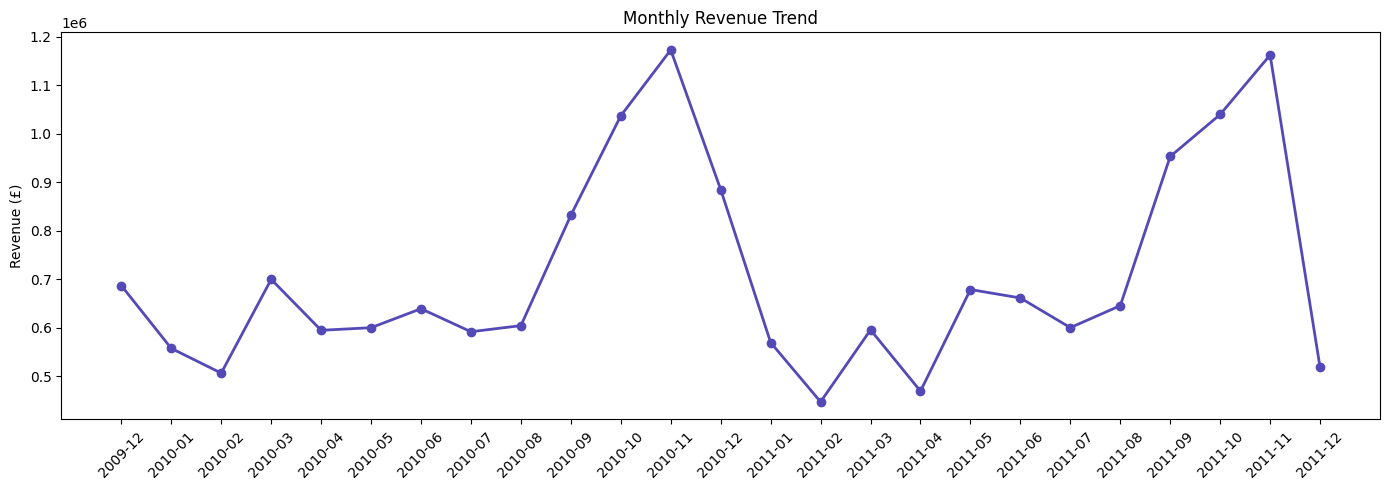

In [3]:
#Chart 1 Monthly Revenue Trend
monthly = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(14,5))
plt.plot(monthly['Period'], monthly['Revenue'], marker='o', linewidth=2, color='#534AB7')

plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (£)')

plt.tight_layout()

plt.savefig('charts_monthly_revenue.png', dpi=150)

plt.show()

1. Revenue shows clear seasonality, with peaks in November each year.
2. Sales are lower in early months(Jan-Feb), indicating slower periods.
3. A sharp drop in Dec 2011 suggest possible incompelte data or post-season decline.
4. Overall, revenue shows fluctuating but growing trends.

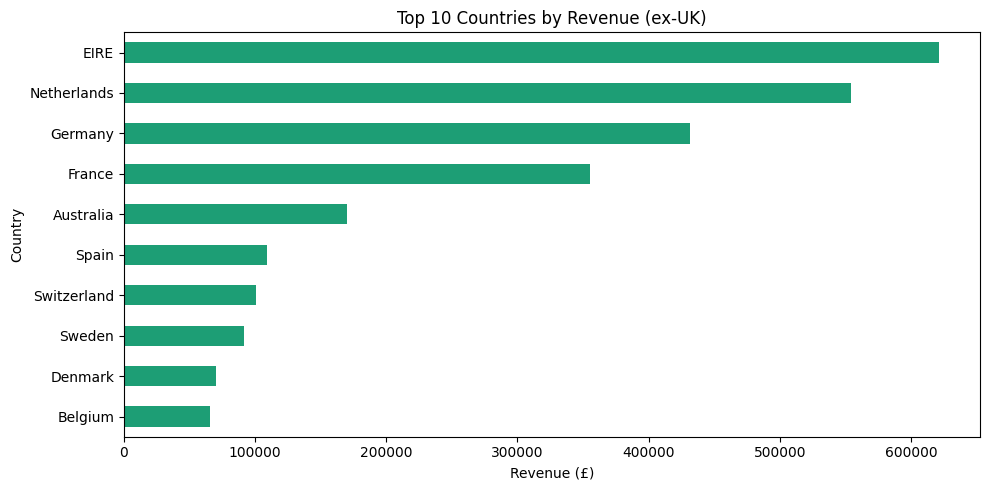

In [4]:
# Chart 2 Top 10 Countries by revenue

country_rev = (
    df[df['Country'] != 'United Kingdom'].groupby('Country')['Revenue'].sum().nlargest(10)
)

plt.figure(figsize=(10,5))

country_rev.sort_values().plot(kind='barh', color = '#1D9E75')

plt.title('Top 10 Countries by Revenue (ex-UK)')
plt.xlabel('Revenue (£)')

plt.tight_layout()

plt.savefig('chart_top_countries.png', dpi=150)

plt.show()

1. Ireland(EIRE) leads revenue, followed by Netherlands and Germany.
2. Revenue is highly concentrated in top 3 countries
3. France and Australia are mid-level contributors.
4. Remaining countries form a low-revenue long tail.
5. suggests focus on top markets + growth in mid-tier regions.

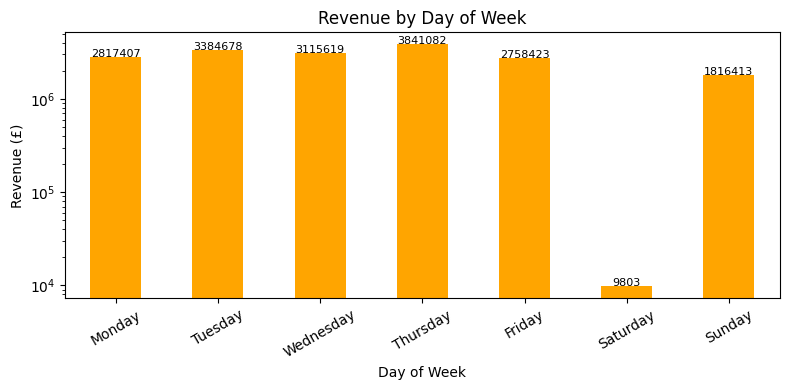

In [15]:
# Chart 3 Revenue by Day of Week

dow_rev = df.groupby('DayOfWeek')['Revenue'].sum()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_rev = dow_rev.reindex(days_order)

plt.figure(figsize=(8,4))
ax = dow_rev.plot(kind='bar', color='orange')

plt.title('Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue (£)')

plt.xticks(rotation=30)

for i, v in enumerate(dow_rev):
    ax.text(i, v, f'{int(v)}', ha='center', fontsize=8)

plt.yscale('log')    

plt.tight_layout()

plt.savefig('chart_day_of_week.png', dpi=150)

plt.show()

1. Thursday generates the highest revenue, making it the peak sales day.
2. Tuesday and Wednesday also perfom strongly, showing consistent mid-week demand.
3. Saturday has extremely low revenue despite having transactions, suggesting very low-value purchases.
4. Sunday shows moderate recovery, but still lower than weekdays.

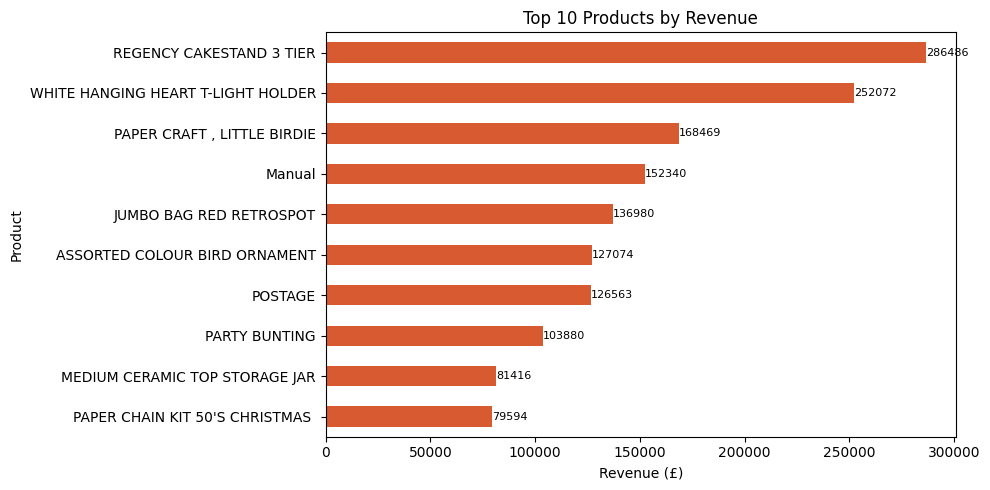

In [16]:
# Chart 4 Top 10 Products by Revenue

top_products = df.groupby('Description')['Revenue'].sum()

top_products = top_products.nlargest(10)

top_products = top_products.sort_values()

plt.figure(figsize=(10,5))
ax = top_products.plot(kind = 'barh', color = '#D85A30')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('Product')

for i, v in enumerate(top_products):
    ax.text(v, i, f'{int(v)}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('chart_top_products.png', dpi=150)

plt.show()

1. Regency cakestand 3 tier is the top revenue generator, clearly leading the product lineup.
2. White hanging heart t-light holder is the second best performer, showing strong demand.
3. Revenue drops gradually after the top2, indicating moderate concentration at the top.
4. A mix of home decor and gifting items dominate, suggesting customer preference trends.
5. Lower-ranked products still contribute steadily, forming a balanced revenue distribution.

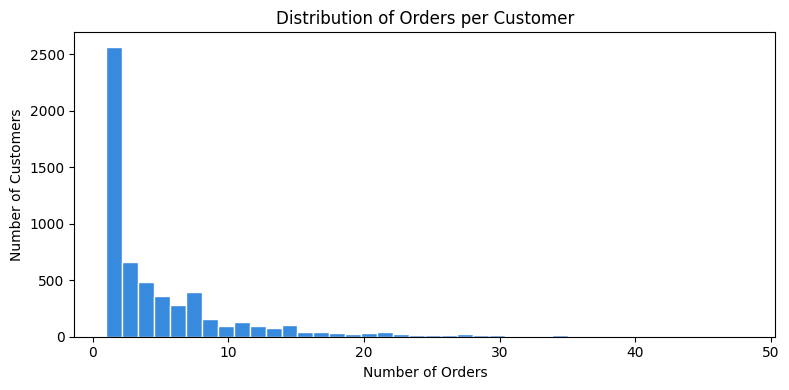

In [17]:
# Chart 5 Customer Distribution - orders per customer
orders_per_cust = df.groupby('Customer ID')['Invoice'].nunique()

filtered_orders = orders_per_cust[orders_per_cust < 50]

plt.figure(figsize=(8,4))
plt.hist(filtered_orders, bins=40, color='#378ADD', edgecolor='white')

plt.title('Distribution of Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('chart_order_distribution.png',  dpi=150)

plt.show()

1. Majority of customers place very few orders(1-3), indicating a large base of low-frequency buyers.
2. The distribution is right-skewed, with a long tail of customers making many orders.
3. A small group of loyal customers contributes to higher order counts.
4. Opportunity to improve retention and increase repeat orders among one-time buyers.

In [23]:
df.dtypes

Invoice          int64
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID      int64
Country         object
Revenue        float64
Year             int64
Month            int64
Month_Name      object
Week             int64
DayOfWeek       object
dtype: object

In [25]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

RFM TABLE

In [26]:
# Set analysis date = 1 day after last invoice

analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency = ('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary = ('Revenue', 'sum')
).reset_index()

rfm['Monetary'] =rfm['Monetary'].round(2)
print(rfm.head())
print(rfm.describe())

rfm.to_csv('rfm_raw.csv', index=False)

   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   5633.32
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40
        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616734
std     1715.572666   209.338707    13.009406   14737.731038
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.000000    2307.090000
max    18287.000000   739.000000   398.000000  608821.650000
